# Anomaly Detection

## Imports & Data Assumptions

Assumption: The model was trained on the complete training dataset, assuming it predominantly consisted of normal samples.

In [14]:
import os
from glob import glob
import h5py
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import random
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, CSVLogger
from PIL import Image

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Data Handling

In [4]:
train_path = '/content/drive/My Drive/lhc_dataset/dataset/train'
val_path = '/content/drive/My Drive/lhc_dataset/dataset/val'

val_file = [os.path.join(val_path, f) for f in os.listdir(val_path) if f.endswith('.h5')]

train_file = [os.path.join(train_path, f) for f in os.listdir(train_path) if f.endswith('.h5')]

In [5]:
def h5_batch_generator(file_list, batch_size=32):
    while True:
        for file_path in file_list:
            with h5py.File(file_path, 'r') as f:
                images = f['jetImage'][:]  # shape: (10000,100,100)

                idx = np.arange(len(images))
                np.random.shuffle(idx)
                images = images[idx]

                for i in range(0, len(images), batch_size):
                    batch_images = images[i:i+batch_size]
                    batch_images = batch_images.reshape(-1,100,100,1).astype('float32') / 255
                    yield batch_images, batch_images

In [6]:
def total_img(file_list, dataset_name = 'jetImage'):
  total = 0
  for fpath in file_list:
    with h5py.File(fpath, 'r') as f:
      total += f[dataset_name].shape[0]
  return total



## CNN Autoencoder
### Architecture:
Autoencoders are a class of unsupervised neural networks which compresses the input into a lower-dimensional code(latent space/bottleneck), and then it reconstructs the output from this representation.
![Architecture](https://ml-cheatsheet.readthedocs.io/en/latest/_images/autoencoder_2.png "Architecture of CNN Autoencoder")
The autoencoder is trained to minimize the Reconstruction Loss which measures how different the reconstructed output is from the original input. Here the loss function is chosen to be Mean Square Error.

In [ ]:
channels = 1 #grayscale images

input_shape = (100,100,1)
inputs = layers.Input(shape=input_shape)
latent_dim = 64
#Functional API format is preferred, since it allows more flexibility.

#encoder
x = layers.Conv2D(32, (3,3), activation = 'relu', padding = 'same')(inputs)
x = layers.MaxPooling2D((2,2), padding='same')(x)
x = layers.Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = layers.MaxPooling2D((2,2), padding='same')(x)
x = layers.Conv2D(128, (3,3), activation='relu', padding='same')(x)
x = layers.MaxPooling2D((2,2), padding='same')(x)

#bottleneck
shape_before_flatten = x.shape[1:]
x = layers.Flatten()(x)
latent = layers.Dense(latent_dim, activation = 'relu')(x)

#decoder
x = layers.Dense(np.prod(shape_before_flatten))(latent)
x = layers.Reshape(shape_before_flatten)(x)
x = layers.Conv2DTranspose(128, (3,3), strides=2, activation='relu', padding='same')(x)

x = layers.Conv2DTranspose(64, (3,3), strides=2, activation='relu', padding='same')(x)

x = layers.Conv2DTranspose(32, (3,3), strides=2, activation='relu', padding='same')(x)

x = layers.Cropping2D(((2,2),(2,2)))(x) #adjusts for size mismatch caused by rounding in pooling/upsampling operations
outputs = layers.Conv2D(1, (3,3), activation='sigmoid', padding='same')(x)

autoencoder = models.Model(inputs, outputs)
autoencoder.compile(optimizer = 'adam', loss = 'mse', metrics = ['mse'])
autoencoder.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 100, 100, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 100, 100, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 50, 50, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 25, 25, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 13, 13, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 21632)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │     1,384,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 21632)          │     1,406,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_3 (Reshape)             │ (None, 13, 13, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_10             │ (None, 26, 26, 128)    │       147,584 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_11             │ (None, 52, 52, 64)     │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_12             │ (None, 104, 104, 32)   │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cropping2d (Cropping2D)         │ (None, 100, 100, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 100, 100, 1)    │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,123,393 (11.91 MB)

 Trainable params: 3,123,393 (11.91 MB)

 Non-trainable params: 0 (0.00 B)

<img src='https://drive.google.com/uc?export=view&id=1-cPbY56_Hhc8q6vr6kjKoZX_Hs9YitwP'>

### Bottleneck Size
The bottleneck size of 64 represents a strong compression ratio. It forces the model to learn a compact and informative representation of the input data, with robust feature extraction. A bottleneck size smaller than 64 could have perhaps led to a lossy reconstruction.

## Training the Model

In [ ]:
folder_path = '/content/drive/My Drive/lhc_dataset/'
checkpoint = ModelCheckpoint(folder_path + 'best_model_anomaly.h5', save_best_only = True, monitor = 'val_loss', mode='min')
csv_log = CSVLogger(folder_path + 'training_log_anomaly.csv', append = True)

#to prevent overfitting
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-5, verbose=1)#reduces learning rate
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)#stops epochs

In [ ]:
batch_size = 32
steps_per_epoch = total_img(train_file) //batch_size
validation_steps = total_img(val_file) //batch_size
train_gen = h5_batch_generator(train_file, batch_size=batch_size)
val_gen = h5_batch_generator(val_file, batch_size=batch_size)

#train
history = autoencoder.fit(
    train_gen,
    epochs = 50,
    steps_per_epoch = steps_per_epoch,
    shuffle = True,
    validation_data = val_gen,
    validation_steps = validation_steps,
    callbacks = [checkpoint, csv_log, reduce_lr, early_stop]
)

Epoch 1/50
8125/8125 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0030 - mse: 0.0030

8125/8125 ━━━━━━━━━━━━━━━━━━━━ 397s 48ms/step - loss: 0.0030 - mse: 0.0030 - val_loss: 4.5866e-04 - val_mse: 4.5866e-04 - learning_rate: 0.0010
Epoch 2/50
8125/8125 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 4.5884e-04 - mse: 4.5884e-04

8125/8125 ━━━━━━━━━━━━━━━━━━━━ 361s 44ms/step - loss: 4.5884e-04 - mse: 4.5884e-04 - val_loss: 4.5854e-04 - val_mse: 4.5854e-04 - learning_rate: 0.0010
Epoch 3/50
8125/8125 ━━━━━━━━━━━━━━━━━━━━ 382s 47ms/step - loss: 4.5866e-04 - mse: 4.5866e-04 - val_loss: 4.5857e-04 - val_mse: 4.5857e-04 - learning_rate: 0.0010
Epoch 4/50
8125/8125 ━━━━━━━━━━━━━━━━━━━━ 361s 44ms/step - loss: 4.5852e-04 - mse: 4.5852e-04 - val_loss: 4.5868e-04 - val_mse: 4.5868e-04 - learning_rate: 0.0010
Epoch 5/50
8125/8125 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 4.5872e-04 - mse: 4.5872e-04
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
8125/8125 ━━━━━━━━━━━━━━━━━━━━ 380s 47ms/step - loss: 4.5872e-04 - mse: 4.5872e-04 - val_loss: 4.5859e-04 - val_mse: 4.5859e-04 - learning_rate: 0.0010
Epoch 6/50
8125/8125 ━━━━━━━━━━━━━━━━━━━━ 361s 44ms/step - loss: 4.5905e-04 - mse: 4.5905e-04 - val_loss: 4.5860e-04 - val_mse: 4.5860e-04 - learning_rate: 5.0000e-04
Epoch 7/50
8125/8125 ━━━━━━━━━━━━━━

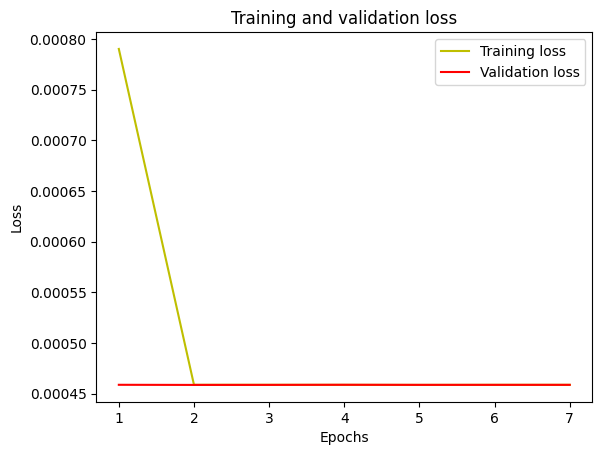

In [ ]:
# training and validation loss visualisation
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'y', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

## Reconstruction Error

### Loading the model

In [7]:
autoencoder = models.load_model('/content/drive/My Drive/lhc_dataset/best_model_anomaly.h5', compile = False)

autoencoder.compile(optimizer = 'adam', loss = 'mse', metrics = ['mse'])

### Distribution of Errors

In [9]:
def compute_reconstruction_errors(file_list, batch_size=32):
    errors = []
    imgs_store = []  # for plotting top anomalies
    gen = h5_batch_generator(file_list, batch_size=batch_size)
    steps = total_img(file_list) // batch_size
    for _ in range(steps):
        batch, _ = next(gen)
        batch_pred = autoencoder.predict(batch)
        batch_err = np.mean((batch - batch_pred)**2, axis=(1,2,3))
        errors.extend(batch_err)
        imgs_store.extend(batch)
    return np.array(errors), np.array(imgs_store)

err, imgs_for_plot = compute_reconstruction_errors(train_file[:1]) #computation power allowed it to be calculated on for a file

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 718ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 432ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 630ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 424ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 451ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 444ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 447ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 436ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 428ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 451ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 424ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 444ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 421ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 866ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 911ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 933ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 813ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 491ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 472ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 432ms/step
1

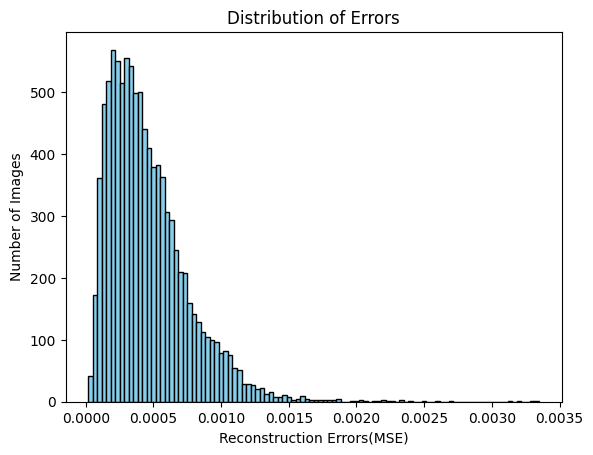

In [12]:
plt.hist(err, bins=100, color='skyblue', edgecolor='black')
plt.xlabel('Reconstruction Errors(MSE)')
plt.ylabel('Number of Images')
plt.title('Distribution of Errors')
plt.show()

### Proposing A Threshold

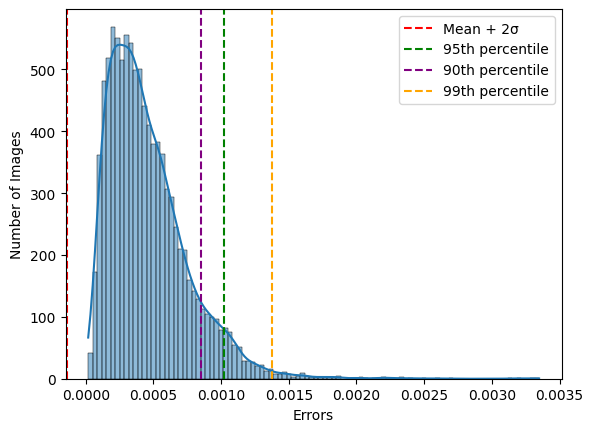

In [19]:
mean_2_sigma = np.mean(err) - 2*np.std(err)
perc_95 = np.percentile(err,95)
perc_90 = np.percentile(err, 90)
perc_99 = np.percentile(err, 99)
# plt.hist(err, bins=100, color='skyblue', edgecolor='black')
sns.histplot(err, bins = 100, kde = 'True')
plt.axvline(mean_2_sigma, color='red', linestyle='--', label='Mean + 2σ')
plt.axvline(perc_95, color='green', linestyle='--', label='95th percentile')
plt.axvline(perc_90, color='purple', linestyle='--', label='90th percentile')
plt.axvline(perc_99, color='orange', linestyle='--', label='99th percentile')
plt.xlabel('Errors')
plt.ylabel("Number of Images")
plt.legend()
plt.show()

Justification of Threshold

In [20]:
threshold = np.percentile(err, 95)  # top 5% as anomalies

A Statistical Threshold was not chosen since distribution of errors was not perfectly Gaussian.<br>
Percentile based Threshold provided a more robust way to identify anomalies.<br>
Lower Thresholds like 90%ile allowed higher sensitivity but also showed more 'normal' jets flagged.
<br>
Higher Thresholds like 99%ile could risk missing rare events.
<br>
Hence, a threshold of 95%ile appeared to be the best middleground.

### Visualisation & Analysis

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


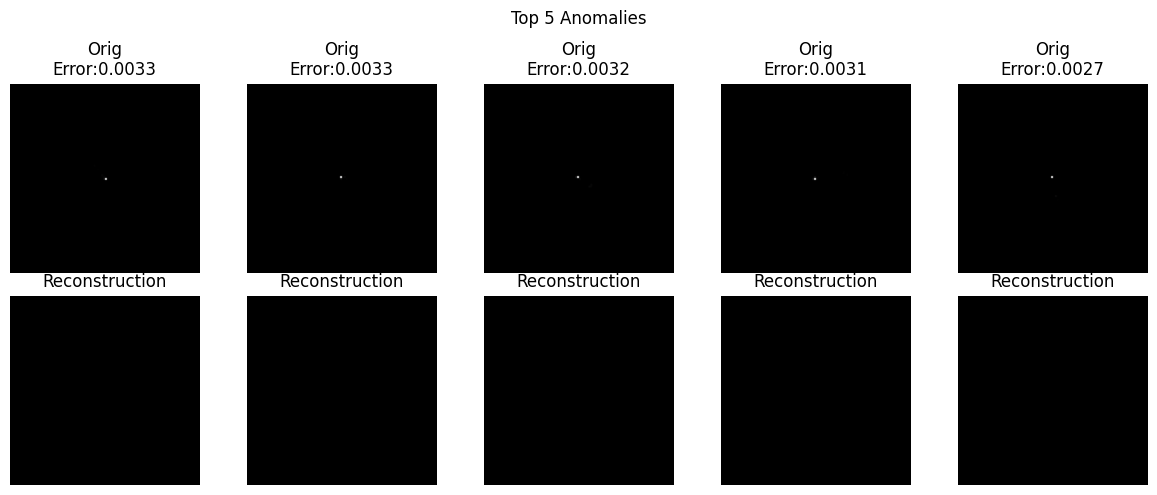

In [21]:
#top five anomalies
top5 = np.argsort(err)[-5:][::-1]
plt.figure(figsize=(12,5))
for i, idx in enumerate(top5):
    # Original
    plt.subplot(2,5,i+1)
    plt.imshow(imgs_for_plot[idx].squeeze(), cmap='gray')
    plt.title(f'Orig\nError:{err[idx]:.4f}')
    plt.axis('off')
    # Reconstruction
    plt.subplot(2,5,i+6)
    recon = autoencoder.predict(imgs_for_plot[idx][np.newaxis,...])
    plt.imshow(recon.squeeze(), cmap='gray')
    plt.title('Reconstruction')
    plt.axis('off')
plt.suptitle('Top 5 Anomalies')
plt.tight_layout()
plt.show()

In [22]:
anomalies = np.where(err > threshold)[0]
print('Total number of anomalies(in first file):', len(anomalies))

Total number of anomalies(in first file): 500


### What can anomalies correspond to?<br>
The CNN Autoencoder was trained only on jet images, under the assumption that most of them correspond to normal jets.<br>
The anomalies can possibly correspond to:
- Rare Standard Model Processes: processes within the standard model, but rare.
- Beyond Standard Model Processes: exotic decays or dark matter candidates can produce jet images that differ largely from the training set.
- Instrumental Noise